# Operando Protocol Simulation: Multi-Stage Temperature Schedule & Multi-nuclear NMR

**Project:** BatteryAsTank / Atom-to-Reactor  
**Author:** Yeray Alcaraz Galván  
**Affiliation:** Department of Chemistry – Ångström Laboratory, Uppsala University  
**Supervisor:** Prof. Peter Broqvist  

This notebook simulates the complete experimental bench protocol for tris(trimethylsilyl) phosphate (TMSPA) hydrolysis in wet ethylene carbonate (EC) across a stepped temperature program ($20^\circ\text{C} \to 80^\circ\text{C}$). It couples the rigorous statistical mechanics and microkinetics engine with multi-nuclear operando NMR spectroscopy ($^{29}\text{Si}, ^{31}\text{P}, ^{13}\text{C}, ^{1}\text{H}$) and fast proton chemical exchange.


In [1]:
import sys
import os
sys.path.insert(0, '..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kinetics import (
    compute_recipe_molarities,
    build_default_protocol_schedule,
    simulate_protocol_reactor,
    build_referenced_nmr_sites,
    simulate_multinuclear_spectra,
    site_peaks,
    auto_regions,
    compute_water_mass_balance,
    lorentzian,
    DEFAULT_NUCLEI
)

# Plotting publication style
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.family': 'sans-serif',
    'figure.dpi': 150,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

print("Environment and kinetics package imported successfully.")


Environment and kinetics package imported successfully.


## 1. Volumetric Recipe to Solution Molarities

Translates operator bench volumes ($2\text{ vol}\% \text{ H}_2\text{O}$ stock, $5\text{ vol}\% \text{ TMSPA}$ addition) into molarities using component densities and molar masses. Models the physical dilution factor $(1 - \phi_{\text{TMSPA}} = 0.95)$ upon injection.


In [2]:
recipe = compute_recipe_molarities(
    h2o_vol_frac_stock=0.02,
    tmspa_vol_frac=0.05
)

print(f"H2O : TMSPA initial molar ratio = {recipe['h2o_tmspa_ratio']:.2f} : 1 (Water in large excess)")
recipe['summary_df'].round(4)


H2O : TMSPA initial molar ratio = 7.04 : 1 (Water in large excess)


,vol% (final),stock (M),after injection (M)
EC,93.1,14.7008,13.9657
H2O,1.9,1.1069,1.0515
TMSPA,5.0,0.0000,0.1494


## 2. Multi-Stage Experimental Protocol Schedule

Defines the chronological sequence:
1. Pre-equilibration stirring at $20^\circ\text{C}$ ($24\text{ h}$).
2. Settling at $20^\circ\text{C}$ ($12\text{ h}$).
3. **Discrete injection of TMSPA** (anchored at $t = 0$).
4. Stepwise temperature holds ($20, 30, 40, 50, 60, 70, 80^\circ\text{C}$, $8\text{ h}$ each).
5. Room temperature ($20^\circ\text{C}$) acquisition hold ($1\text{ h}$) after each temperature step.


In [3]:
stages, sched_df = build_default_protocol_schedule()
sched_df


,stage,T (°C),duration (h),start (h),end (h),acquisition
0,"EC + H2O, stirred",20.0,24.0,-36.0,-12.0,
1,equilibrate,20.0,12.0,-12.0,0.0,
2,hold 20 C,20.0,8.0,0.0,8.0,
3,acquire (20 C),20.0,1.0,8.0,9.0,20 °C
4,hold 30 C,30.0,8.0,9.0,17.0,
5,acquire (30 C),20.0,1.0,17.0,18.0,30 °C
6,hold 40 C,40.0,8.0,18.0,26.0,
7,acquire (40 C),20.0,1.0,26.0,27.0,40 °C
8,hold 50 C,50.0,8.0,27.0,35.0,
9,acquire (50 C),20.0,1.0,35.0,36.0,50 °C


## 3. Piecewise Stiff ODE Simulation (Radau IIA)

Integrates stage by stage using implicit Radau IIA Runge-Kutta. Rate constants are evaluated dynamically at each stage setpoint using the finite-temperature microkinetics engine.


In [4]:
sim = simulate_protocol_reactor(
    stages=stages,
    recipe=recipe,
    points_per_stage=120
)

print(f"Simulation completed: {sim['t_h'][-1]:.1f} hours.")
print(f"TMSPA remaining: {sim['snapshots'][-1]['C'][sim['idx']['TMSPA']]*1000:.3f} mM "
      f"({sim['snapshots'][-1]['C'][sim['idx']['TMSPA']]/recipe['after']['TMSPA']*100:.2f}%)")
print(f"Silicon element conserved: {sim['si_conserved']}")
print(f"Phosphorus element conserved: {sim['p_conserved']}")


Simulation completed: 63.0 hours.
TMSPA remaining: 0.037 mM (0.02%)
Silicon element conserved: True
Phosphorus element conserved: True


## 4. Concentration Trajectories Through Protocol


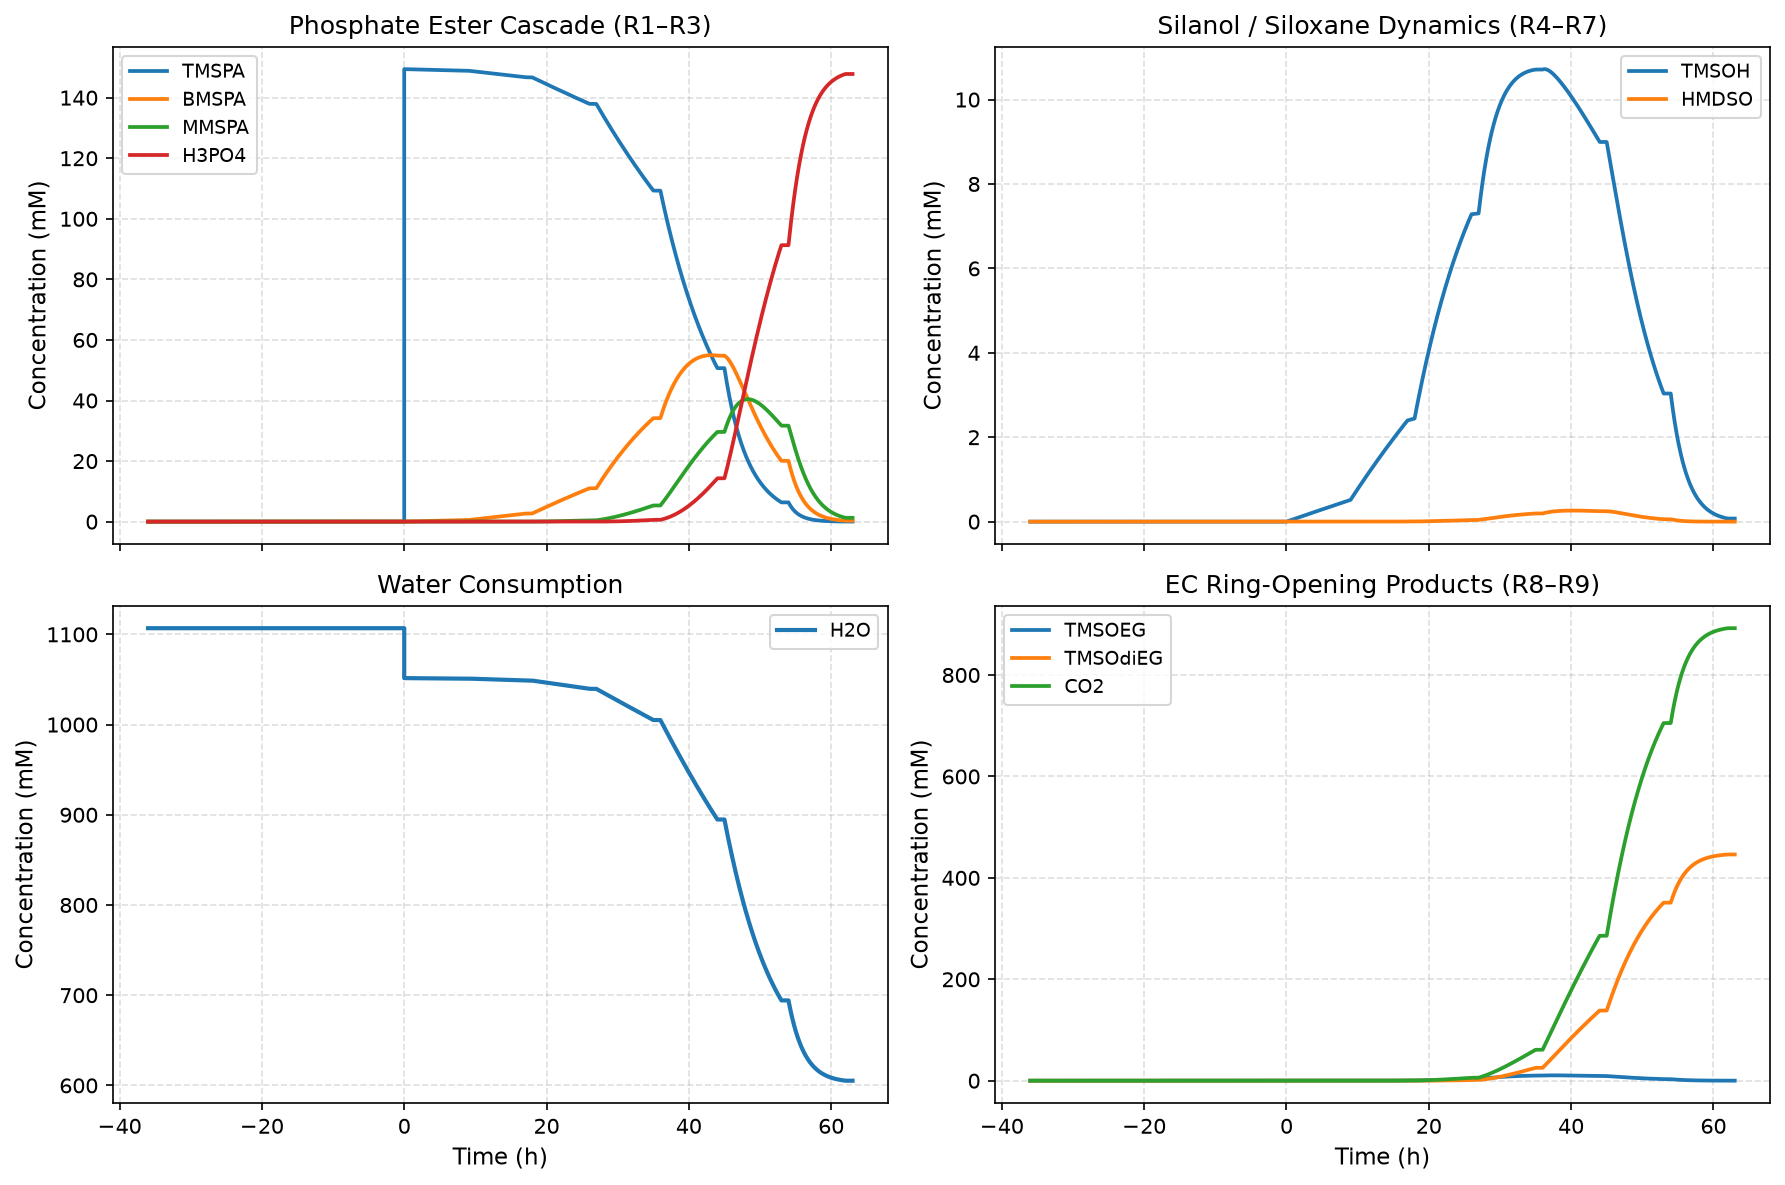

In [5]:
t_h = sim['t_h']
C_mM = sim['C_mM']
idx = sim['idx']

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Phosphate ladder
ax = axes[0, 0]
for sp in ['TMSPA', 'BMSPA', 'MMSPA', 'H3PO4']:
    ax.plot(t_h, C_mM[idx[sp]], lw=1.8, label=sp)
ax.set_ylabel('Concentration (mM)')
ax.set_title('Phosphate Ester Cascade (R1–R3)')
ax.legend(frameon=True)
ax.grid(True)

# Silanol / Siloxane
ax = axes[0, 1]
for sp in ['TMSOH', 'HMDSO']:
    ax.plot(t_h, C_mM[idx[sp]], lw=1.8, label=sp)
ax.set_ylabel('Concentration (mM)')
ax.set_title('Silanol / Siloxane Dynamics (R4–R7)')
ax.legend(frameon=True)
ax.grid(True)

# Water
ax = axes[1, 0]
ax.plot(t_h, C_mM[idx['H2O']], color='C0', lw=2.0, label='H2O')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Concentration (mM)')
ax.set_title('Water Consumption')
ax.legend(frameon=True)
ax.grid(True)

# Solvent attack products
ax = axes[1, 1]
for sp in ['TMSOEG', 'TMSOdiEG', 'CO2']:
    ax.plot(t_h, C_mM[idx[sp]], lw=1.8, label=sp)
ax.set_xlabel('Time (h)')
ax.set_ylabel('Concentration (mM)')
ax.set_title('EC Ring-Opening Products (R8–R9)')
ax.legend(frameon=True)
ax.grid(True)

plt.tight_layout()
plt.show()


## 5. Multi-nuclear Operando NMR Stacked Spectra ($^{29}\text{Si}, ^{31}\text{P}, ^{13}\text{C}, ^{1}\text{H}$)

Generates synthetic operando spectra for each temperature step acquisition using DFT GIAO isotropic shieldings averaged over topological equivalence classes.


/var/folders/p9/lpxbgdp50rqbqty02d2qwksh0000gn/T/ipykernel_94099/1858751444.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


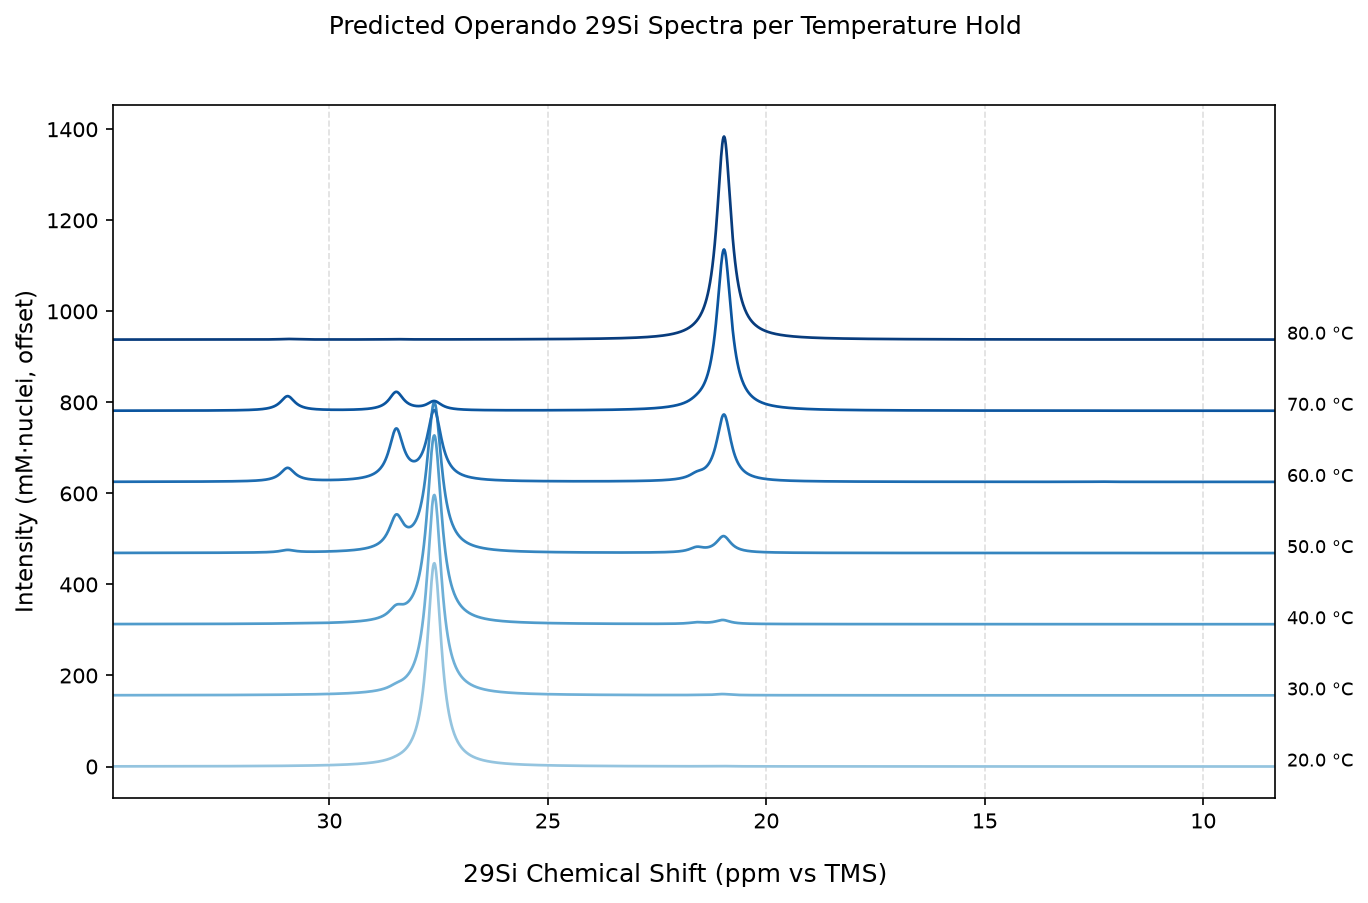

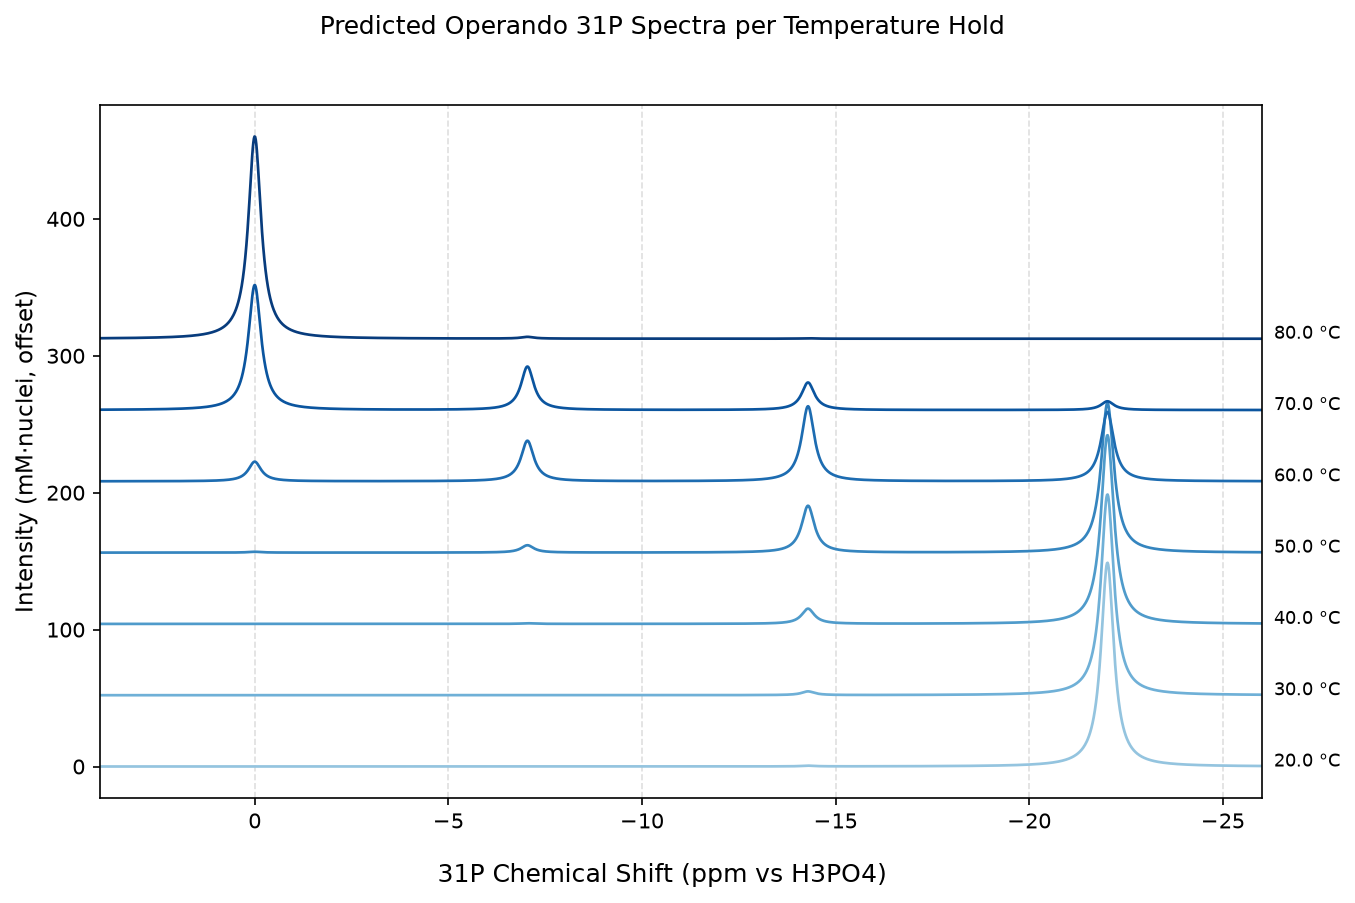

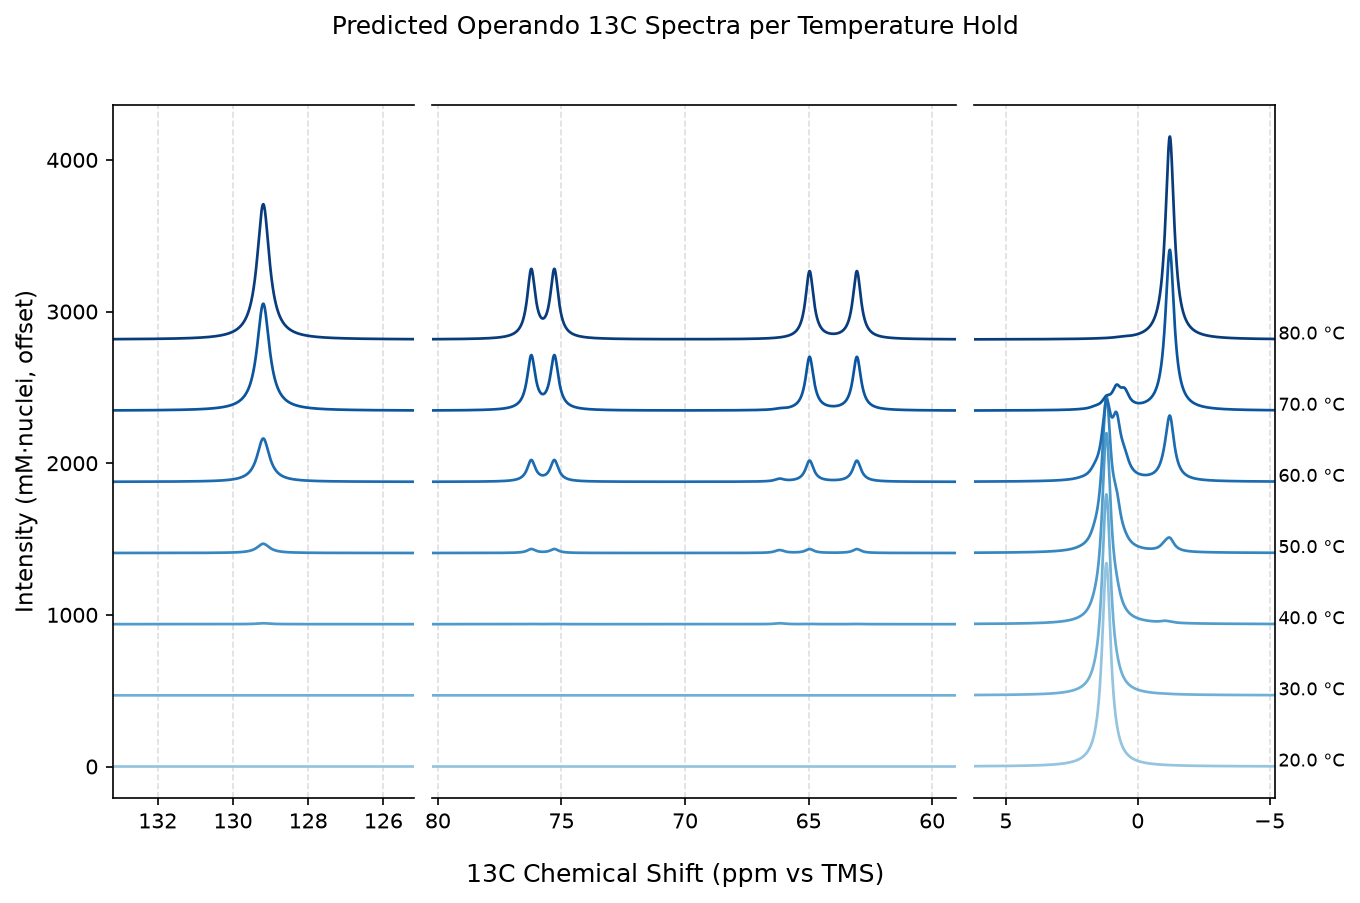

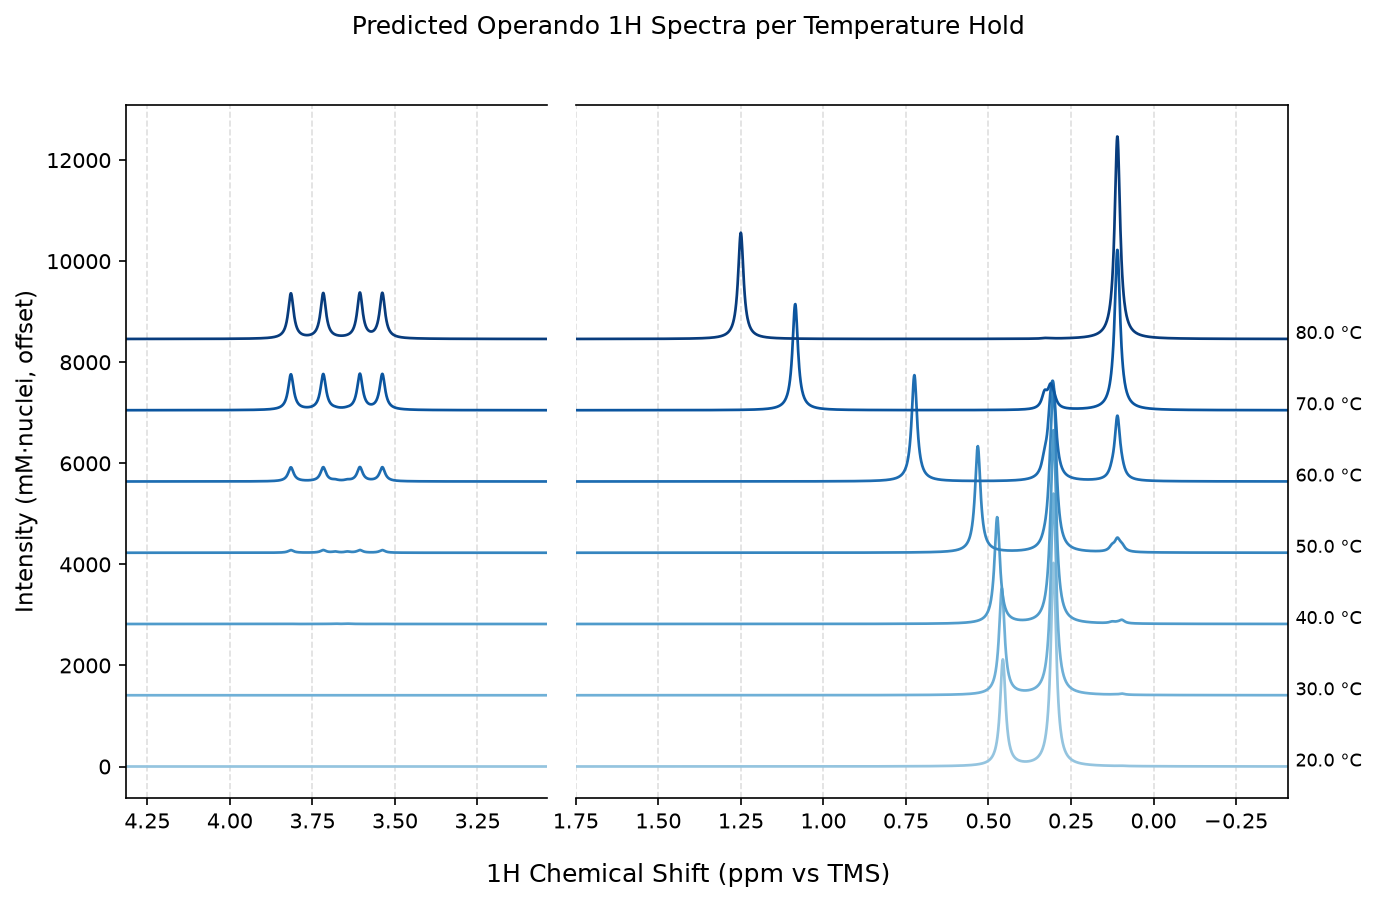

In [6]:
catalog = build_referenced_nmr_sites()

def plot_stacked_spectra(element, lw=0.4, pad=4.0, max_gap=40.0):
    ref, iso = DEFAULT_NUCLEI[element]
    c_snaps = np.array([s['C'] for s in sim['snapshots']]).T
    peaks = site_peaks(element, c_snaps, sim['idx'], nmr_sites_catalog=catalog)
    
    shifts = [d for _, s_vec, _ in peaks for d in [s_vec.min(), s_vec.max()]]
    regions = auto_regions(shifts, pad=pad, max_gap=max_gap)
    widths = [hi - lo for hi, lo in regions]
    ratios = [max(w, 0.3 * sum(widths)) for w in widths]
    grids = [np.linspace(hi, lo, 2000) for hi, lo in regions]
    
    specs = [simulate_multinuclear_spectra(element, c_snaps, sim['idx'], x, lw=lw, nmr_sites_catalog=catalog) for x in grids]
    peak_max = max(s.max() for s in specs)
    step_offset = peak_max * 0.35
    
    fig, axes = plt.subplots(1, len(regions), figsize=(10, 6), sharey=True, gridspec_kw={'width_ratios': ratios, 'wspace': 0.05})
    axes = np.atleast_1d(axes)
    shades = plt.cm.Blues(np.linspace(0.4, 0.95, len(sim['snapshots'])))
    
    for k, (ax, (hi, lo), x, S) in enumerate(zip(axes, regions, grids, specs)):
        for i, col in enumerate(shades):
            ax.plot(x, S[i] + i * step_offset, color=col, lw=1.3)
        ax.set_xlim(hi, lo)
        ax.grid(True, axis='x')
        if k > 0:
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)
        if k < len(axes) - 1:
            ax.spines['right'].set_visible(False)
            
    for i, snap in enumerate(sim['snapshots']):
        axes[-1].annotate(f"{snap['T_C']} °C", xy=(1.01, i * step_offset), xycoords=('axes fraction', 'data'), fontsize=8.5)
        
    fig.supxlabel(f"{iso} Chemical Shift (ppm vs {ref})")
    axes[0].set_ylabel("Intensity (mM·nuclei, offset)")
    fig.suptitle(f"Predicted Operando {iso} Spectra per Temperature Hold")
    plt.tight_layout()
    plt.show()

for el in ['Si', 'P', 'C', 'H']:
    lw_val = 0.02 if el == 'H' else 0.4
    plot_stacked_spectra(el, lw=lw_val, pad=0.5 if el == 'H' else 4.0, max_gap=2.0 if el == 'H' else 40.0)


## 6. Fast Proton Exchange & Water Mass Balance Deduction

Labile protons coalesce into a single population-weighted resonance. Total labile OH concentration is invariant ($2 [\text{H}_2\text{O}]_0$), allowing exact water determination from non-water resonances.


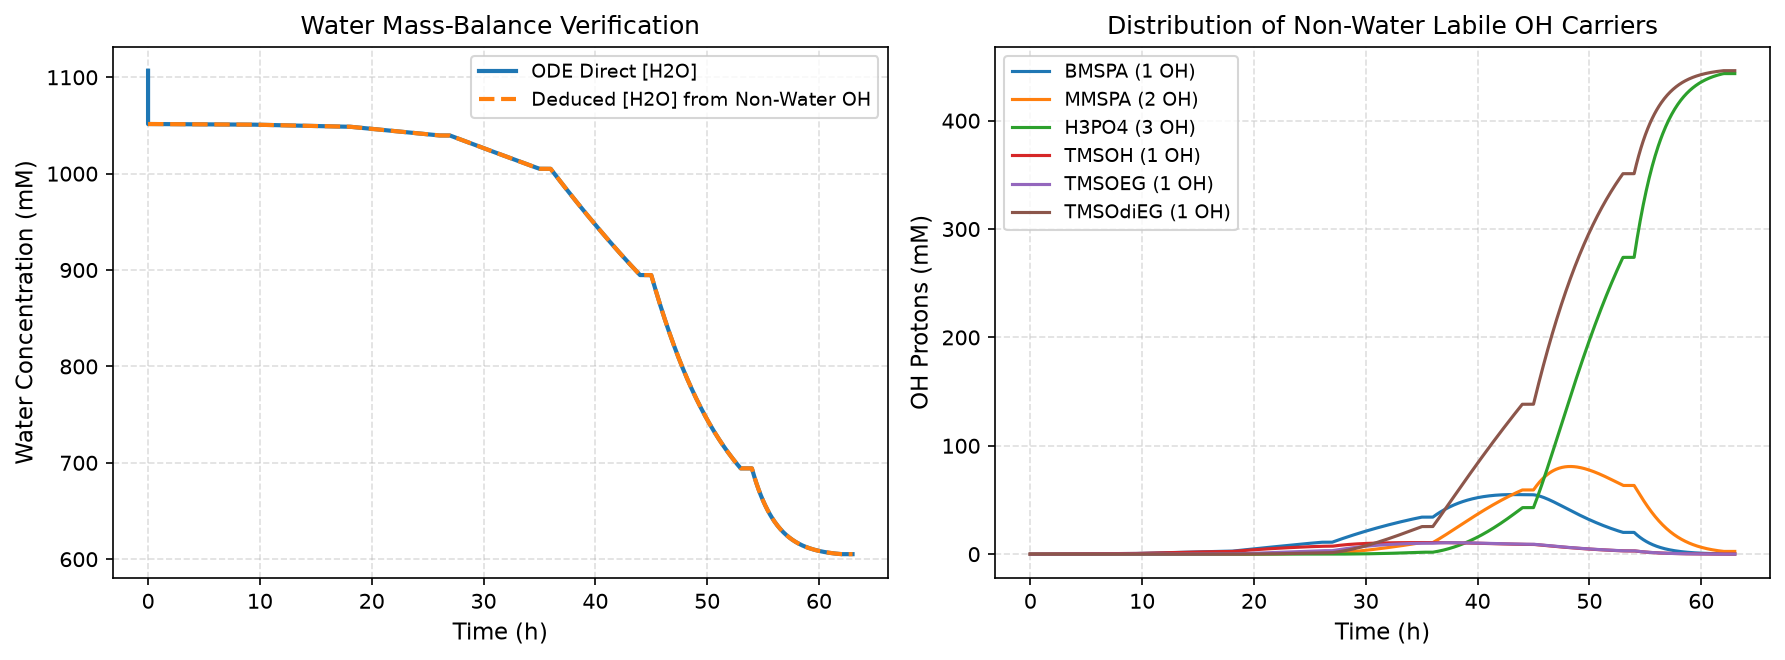

In [7]:
wb = compute_water_mass_balance(
    sim['C_M'],
    sim['idx'],
    initial_h2o_molarity=recipe['after']['H2O'],
    nmr_sites_catalog=catalog
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

post_inj = np.where(sim['t_h'] >= 0)[0]
ax1.plot(sim['t_h'][post_inj], wb['h2o_direct_M'][post_inj]*1000, label='ODE Direct [H2O]', lw=2.0)
ax1.plot(sim['t_h'][post_inj], wb['h2o_deduced_M'][post_inj]*1000, '--', label='Deduced [H2O] from Non-Water OH', lw=2.0)
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Water Concentration (mM)')
ax1.set_title('Water Mass-Balance Verification')
ax1.legend(frameon=True)
ax1.grid(True)

for col in wb['carriers_df'].columns:
    if 'H2O' not in col:
        ax2.plot(sim['t_h'][post_inj], wb['carriers_df'][col].values[post_inj], label=col, lw=1.5)
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('OH Protons (mM)')
ax2.set_title('Distribution of Non-Water Labile OH Carriers')
ax2.legend(frameon=True)
ax2.grid(True)

plt.tight_layout()
plt.show()
